### Overview

In this part of the project I will take a deeper dive into how my Kalman filter changes the properties of my signals by comparing the distribution of returns of the unfiltered and filtered price histories.

In [53]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


import sys
sys.path.append("../src")

# This file contains code that helps me create
# market data based on imposed values
from simulate_gbm_market import Asset, simulate_gbm_market
from kalman_filter import KalmanMatrices, run_kalman

# Retrieve old price histories
%store -r real_filtered
%store -r filtered
%store -r prices
%store -r real_prices

First step is to retrieve the day to day movement of each

In [54]:
real_mvnt = {
    ticker: (real_prices[ticker].values[1:] / real_prices[ticker].values[:-1] - 1) * 100
    for ticker in real_prices.columns
}

real_filtered_mvnt = {
    ticker: (state.price[1:] / state.price[:-1] - 1) * 100
    for ticker, state in real_filtered.items()
}

Same thing for the simulated (2023+) data — this gives us a matched unfiltered/filtered pair to actually compare distributions against, since real data only has the filtered side.

In [55]:
prices_mvnt = {
    ticker: (prices[ticker].values[1:] / prices[ticker].values[:-1] - 1) * 100
    for ticker in prices.columns
}

filtered_mvnt = {
    ticker: (state.price[1:] / state.price[:-1] - 1) * 100
    for ticker, state in filtered.items()
}

In [56]:
real_mvnt_df = pd.DataFrame(real_mvnt)
real_filtered_mvnt_df = pd.DataFrame(real_filtered_mvnt)
prices_mvnt_df = pd.DataFrame(prices_mvnt)
filtered_mvnt_df = pd.DataFrame(filtered_mvnt)

real_mvnt_df.head()

,SPY,TLT,GLD,QQQ
0,-0.845547,0.242646,6.358721,-1.536400
1,-0.484385,-0.253579,-0.070441,-1.746912
2,-1.248928,1.086198,-2.663171,-1.439529
3,1.918479,0.068593,3.073229,2.113797
4,0.482182,-0.022846,2.540291,0.766013


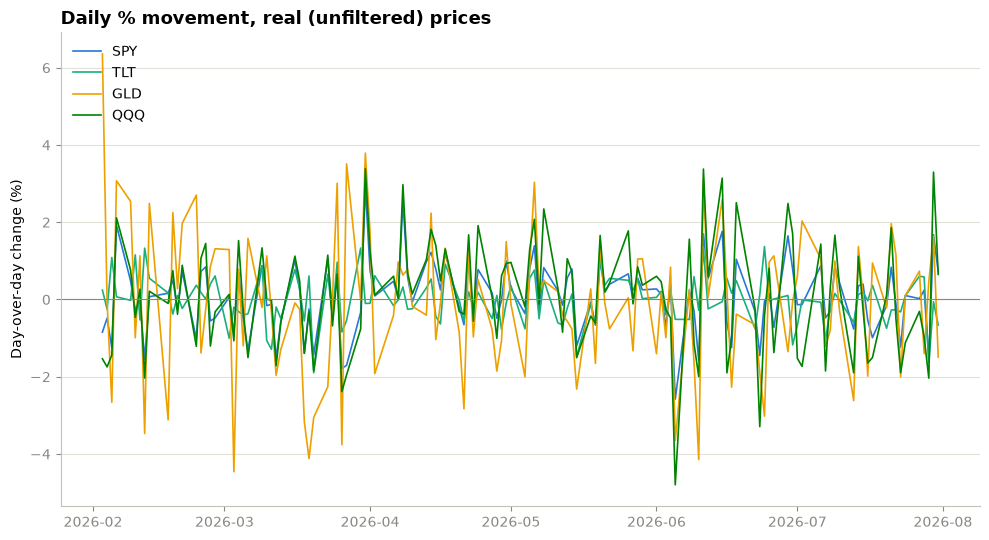

In [57]:
COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300"]

fig, ax = plt.subplots(figsize=(10, 5.5))

for ticker, color in zip(real_mvnt.keys(), COLORS):
    ax.plot(real_prices.index[1:], real_mvnt[ticker], color=color, linewidth=1.2, label=ticker)

ax.axhline(0, color="#898781", linewidth=0.8)

ax.set_title("Daily % movement, real (unfiltered) prices", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Day-over-day change (%)")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")

ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#898781")

ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

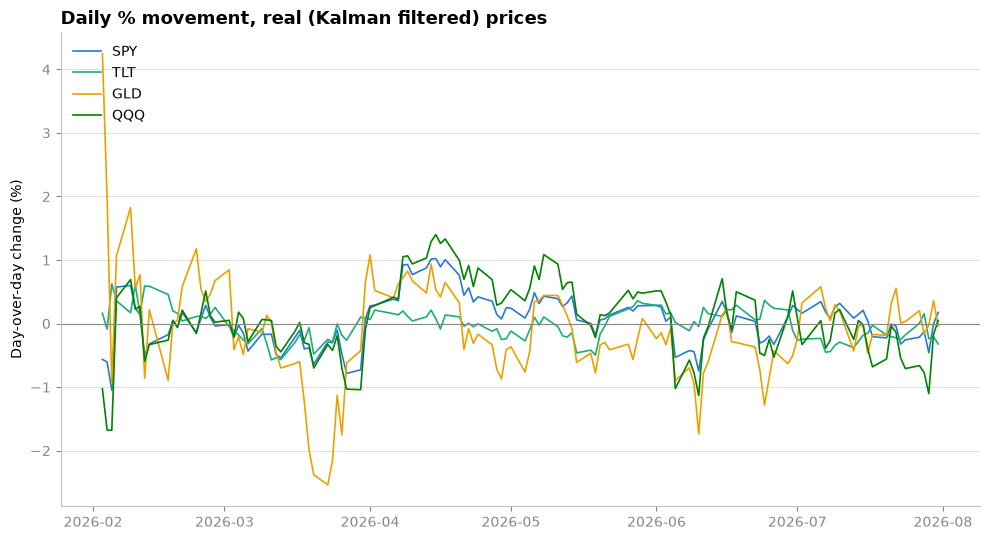

In [58]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for ticker, color in zip(real_filtered_mvnt.keys(), COLORS):
    ax.plot(real_prices.index[1:], real_filtered_mvnt[ticker], color=color, linewidth=1.2, label=ticker)

ax.axhline(0, color="#898781", linewidth=0.8)

ax.set_title("Daily % movement, real (Kalman filtered) prices", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Day-over-day change (%)")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")

ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#898781")

ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

I'll try visualising it as a distribution next